# Summary and Distribution of KataGo 'katago_all' Probabilities

This notebook analyzes the 'katago_all' component from the training dataset, providing a summary table and visualization of the probability distributions.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import numpy as np

# Set style for plots
sns.set_style("whitegrid")

In [2]:
# Load the dataset
data_path = r"C:\git_repo\KataGo-LLM-Team\data\training_data_augmented_shuffled.jsonl"

data = []
with open(data_path, 'r') as f:
    for line in f:
        data.append(json.loads(line))

print(f"Loaded {len(data)} records from the dataset.")

Loaded 4992 records from the dataset.


In [3]:
# Extract all probabilities from katago_all
all_probabilities = []
num_moves_per_record = []

for record in data:
    katago_all = record.get('katago_all', {})
    probabilities = list(katago_all.values())
    all_probabilities.extend(probabilities)
    num_moves_per_record.append(len(probabilities))

print(f"Total number of probability values: {len(all_probabilities)}")
print(f"Average number of moves per record: {np.mean(num_moves_per_record):.2f}")
print(f"Min number of moves: {min(num_moves_per_record)}")
print(f"Max number of moves: {max(num_moves_per_record)}")

Total number of probability values: 41392
Average number of moves per record: 8.29
Min number of moves: 2
Max number of moves: 10


In [4]:
# Compute summary statistics for probabilities
prob_df = pd.Series(all_probabilities)

summary_stats = prob_df.describe()
print("Summary Statistics for KataGo Probabilities:")
print(summary_stats)

# Additional stats
print(f"\nSkewness: {prob_df.skew():.4f}")
print(f"Kurtosis: {prob_df.kurtosis():.4f}")

# Create a summary table
summary_table = pd.DataFrame({
    'Statistic': ['Count', 'Mean', 'Std', 'Min', '25%', '50%', '75%', 'Max'],
    'Value': [summary_stats['count'], summary_stats['mean'], summary_stats['std'], 
              summary_stats['min'], summary_stats['25%'], summary_stats['50%'], 
              summary_stats['75%'], summary_stats['max']]
})
print("\nSummary Table:")
print(summary_table.to_string(index=False))

Summary Statistics for KataGo Probabilities:
count    41392.000000
mean         0.138054
std          0.260811
min          0.000700
25%          0.004930
50%          0.010310
75%          0.095642
max          0.999978
dtype: float64

Skewness: 2.1929
Kurtosis: 3.9169

Summary Table:
Statistic        Value
    Count 41392.000000
     Mean     0.138054
      Std     0.260811
      Min     0.000700
      25%     0.004930
      50%     0.010310
      75%     0.095642
      Max     0.999978


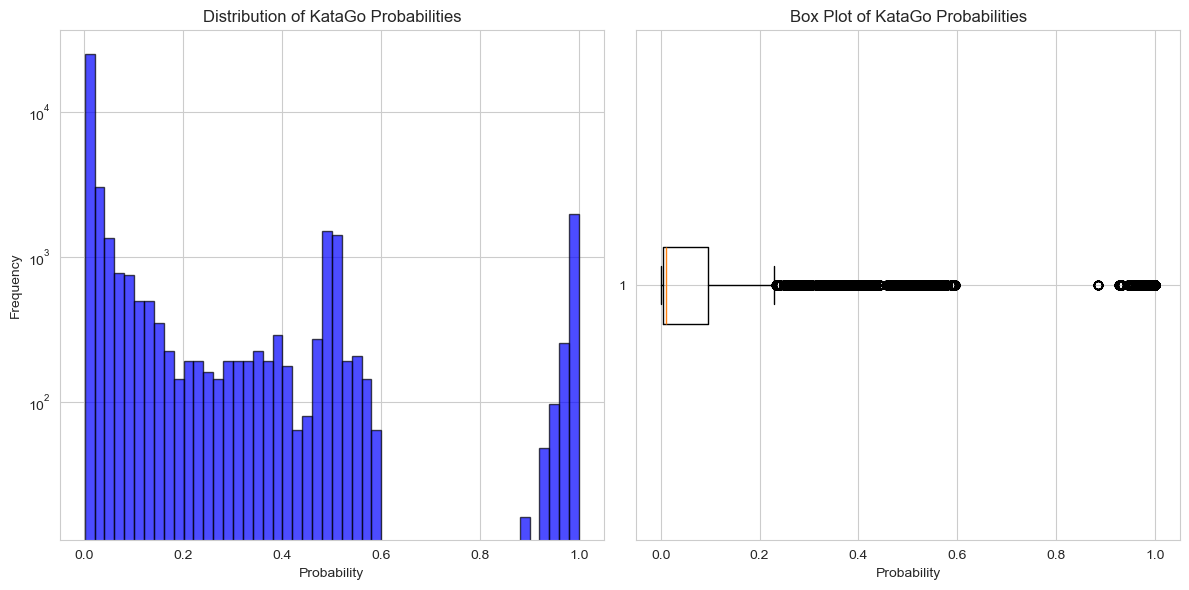

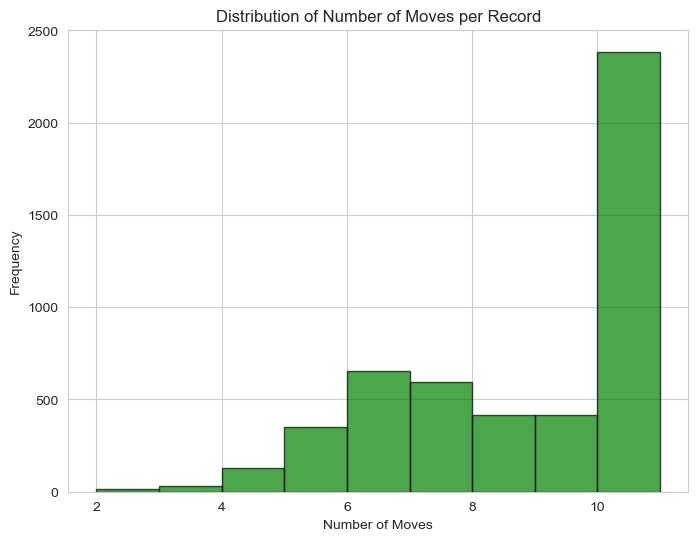

In [6]:
# Visualize the distribution
plt.figure(figsize=(12, 6))

# Histogram
plt.subplot(1, 2, 1)
plt.hist(all_probabilities, bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.title('Distribution of KataGo Probabilities')
plt.xlabel('Probability')
plt.ylabel('Frequency')
plt.yscale('log')  # Since there might be many low values

# Box plot
plt.subplot(1, 2, 2)
plt.boxplot(all_probabilities, vert=False)
plt.title('Box Plot of KataGo Probabilities')
plt.xlabel('Probability')

plt.tight_layout()
plt.show()

# Additional plot: distribution of number of moves per record
plt.figure(figsize=(8, 6))
plt.hist(num_moves_per_record, bins=range(min(num_moves_per_record), max(num_moves_per_record)+2), alpha=0.7, color='green', edgecolor='black')
plt.title('Distribution of Number of Moves per Record')
plt.xlabel('Number of Moves')
plt.ylabel('Frequency')
plt.show()